# Aula 13 - Classificação: Árvores de Decisão, Florestas Aleatórias e SVM

Dataset externo usado nos exemplos: Arzamasov, V. (2018). *Electrical Grid Stability Simulated Data*. UCI Machine Learning Repository. DOI: `10.24432/C5PG66`. Página: https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data

## Onde esta aula se encaixa

- Já vimos KNN, regressão logística e regressão linear.
- Agora: classificadores com fronteiras não lineares e boa interpretação prática.
- Problema-guia: prever se um sistema elétrico simulado está **estável** ou **instável**.
- Comparar Árvores, florestas e SVM por formulação matemática e métricas.
- Sistema: rede estrela de 4 nós, com um produtor central e consumidores.
- Tarefa: classificação binária do campo `stabf`: `stable` ou `unstable`.

## Preparação do ambiente, leitura dos dados e modelos

In [4]:
import urllib.request
import zipfile
from pathlib import Path

from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

DATA_DIR = Path("data")
FIG_DIR = Path("figuras_aula_13_dt_rf_svm")
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

CSV_PATH = DATA_DIR / "Data_for_UCI_named.csv"
ZIP_PATH = DATA_DIR / "electrical_grid_stability_simulated_data.zip"
UCI_ZIP_URL = "https://archive.ics.uci.edu/static/public/471/electrical+grid+stability+simulated+data.zip"

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 220,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    display(plt.gcf())
    plt.close()
    return path


if not CSV_PATH.exists():
    with urllib.request.urlopen(UCI_ZIP_URL, timeout=60) as response:
        ZIP_PATH.write_bytes(response.read())
    with zipfile.ZipFile(ZIP_PATH) as zf:
        member = [m for m in zf.namelist() if m.endswith(".csv")][0]
        CSV_PATH.write_bytes(zf.read(member))


df = pd.read_csv(CSV_PATH)

feature_cols = [c for c in df.columns if c not in ["stab", "stabf", "p1"]]
X = df[feature_cols]
y_text = df["stabf"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)
stable_label = int(label_encoder.transform(["stable"])[0])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=30, random_state=42)
forest = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=10, gamma="scale", random_state=42)),
])

models = {
    "Árvore de decisão": tree,
    "Floresta aleatória": forest,
    "SVM RBF": svm,
}

for model in models.values():
    model.fit(X_train, y_train)

df.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


## Preditores e variável-alvo

- Preditores usados: $\tau_i$, $p_i$ e $g_i$ para os nós consumidores.
- $\tau_i$: tempo de reação do nó $i$.
- $p_i$: potência nominal consumida no nó $i$.
- $g_i$: coeficiente proporcional à elasticidade de preço.
- `stab`: índice contínuo de estabilidade; removido para evitar vazamento.
- `stabf`: rótulo de classe usado no treinamento: `stable`/`unstable`.

Figura usada no slide: balanceamento das classes `stable` e `unstable`.

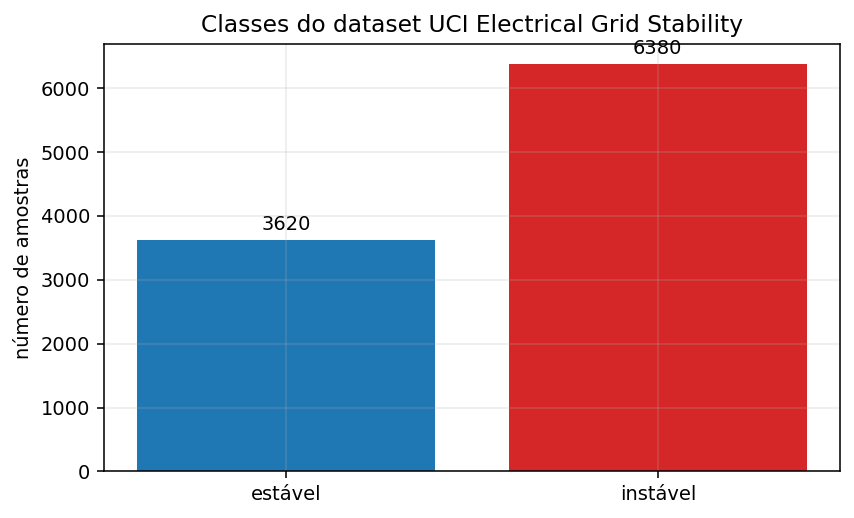

stabf
stable      3620
unstable    6380
Name: count, dtype: int64

In [5]:
counts = y_text.value_counts().reindex(["stable", "unstable"])
fig, ax = plt.subplots(figsize=(6.2, 3.8))
bars = ax.bar(["estável", "instável"], counts.values, color=["#1f77b4", "#d62728"])
ax.set_title("Classes do dataset UCI Electrical Grid Stability")
ax.set_ylabel("número de amostras")
ax.bar_label(bars, padding=3)
savefig("01_balanceamento_classes.png")
counts

## O que torna o problema interessante?

- A figura usa duas variáveis originais: `tau2` e `g2`.
- Pontos estáveis e instáveis aparecem misturados nessa visualização.
- Logo, uma regra simples com apenas uma variável ou uma reta tende a ser insuficiente.
- Precisamos de modelos que combinem várias variáveis e capturem interações.

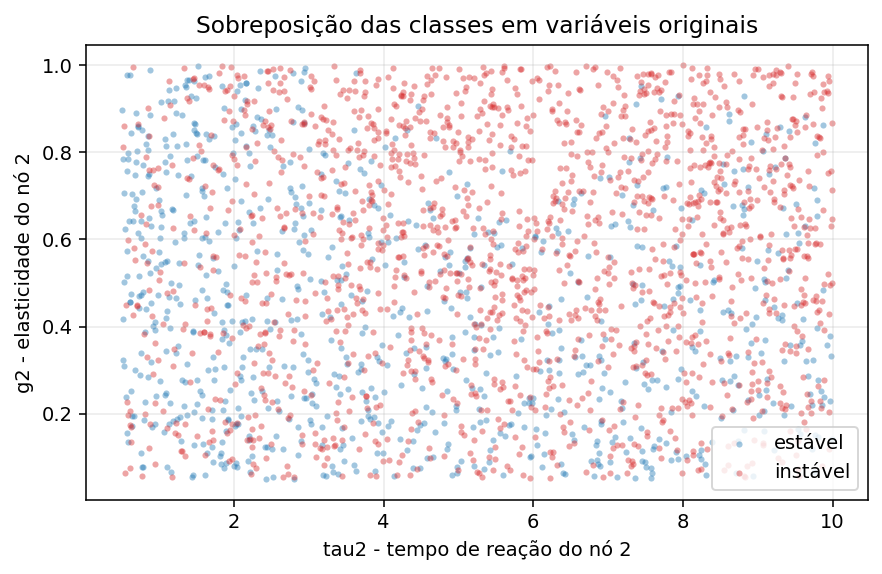

WindowsPath('figuras_aula_13_dt_rf_svm/02_variaveis_originais_classes.png')

In [6]:
sample = df.sample(n=2500, random_state=42)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
colors = {"stable": "#1f77b4", "unstable": "#d62728"}
labels = {"stable": "estável", "unstable": "instável"}
for cls, group in sample.groupby("stabf"):
    ax.scatter(
        group["tau2"], group["g2"], s=10, alpha=0.42,
        c=colors[cls], label=labels[cls], linewidths=0,
    )
ax.set_xlabel("tau2 - tempo de reação do nó 2")
ax.set_ylabel("g2 - elasticidade do nó 2")
ax.set_title("Sobreposição das classes em variáveis originais")
ax.legend(frameon=True, loc="lower right")
savefig("02_variaveis_originais_classes.png")

# Árvores de decisão

## Árvore: sequência de perguntas

- Cada n? interno faz uma pergunta do tipo ``variável <= limiar?''.
- Cada resposta leva a uma nova pergunta ou a uma folha, isto é, um nó terminal que gera a predição.
- A folha prediz a classe mais frequente entre as amostras que chegam ali.

Exemplo conceitual usado no slide:

```text
g2 <= c1?
├── sim:  tau3 <= c2?  -> estável / instável
└── não:  g4 <= c3?    -> estável / instável
```

## Como escolher uma pergunta?

No exemplo da rede elétrica:

- Uma amostra é uma simulação da rede com valores de $\tau_i$, $p_i$ e $g_i$.
- As classes são $k=$ `stable` e $k=$ `unstable`.
- Nó $m$: grupo de dados, isto é, amostras que chegaram ao mesmo ponto da Árvore.
- $n_m$: número de amostras nesse nó.
- $p_{mk}$: proporção da classe $k$ no nó $m$:

$$
p_{mk}=\frac{\text{número de amostras da classe }k\text{ no nó }m}{n_m}.
$$

Ideia: uma boa pergunta cria grupos mais homogêneos: quase tudo `stable` ou quase tudo `unstable`.

## Impureza: a ideia usada pela Árvore

- Nó puro: quase todas as amostras são da mesma classe.
- Nó misturado: há muitas amostras `stable` e `unstable` juntas.
- O `scikit-learn` usa, por padrão, o índice de Gini:

$$
Gini(m)=1-\sum_{k=1}^K p_{mk}^2.
$$

- Gini é 0 para nó puro: tudo `stable` ou tudo `unstable`.
- Gini é máximo quando as classes estão igualmente misturadas: 50% `stable` e 50% `unstable`.
- Treinamento: escolher, em cada nó, a variável e o limiar que mais reduzem a impureza dos filhos.

## Primeiros níveis da Árvore treinada

Figura usada no slide com os primeiros níveis da Árvore treinada.

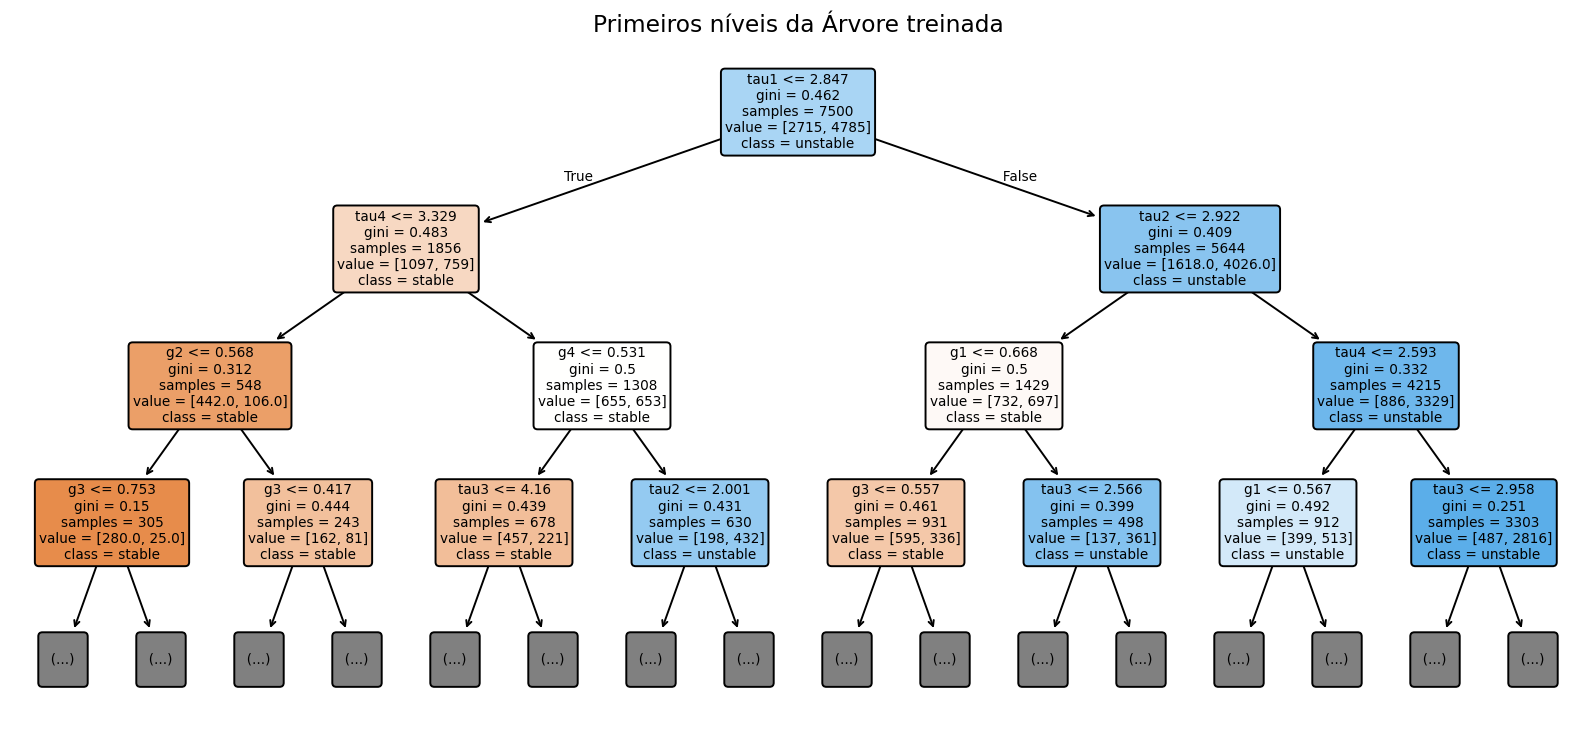

WindowsPath('figuras_aula_13_dt_rf_svm/03_arvore_decisao.png')

In [7]:
fig, ax = plt.subplots(figsize=(11.5, 5.4))
plot_tree(
    tree,
    max_depth=3,
    feature_names=feature_cols,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=7,
    ax=ax,
)
ax.set_title("Primeiros níveis da Árvore treinada")
savefig("03_arvore_decisao.png")

## Pipeline mínimo para treinar uma DT

O código abaixo é o mesmo pipeline mínimo apresentado nos slides.

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

dt = Pipeline([
    ("tree", DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=30,
        random_state=42))
])

dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

Comentários do slide:

- `max_depth`: profundidade máxima; limita a sequência de perguntas.
- `min_samples_leaf`: mínimo de amostras em cada folha.
- Podem ser escolhidos por validação cruzada, por exemplo com `GridSearchCV`.
- `fit`: aprende perguntas; `predict`: retorna `stable`/`unstable`.

# Florestas aleatórias

## Da Árvore única ao comitê

- Uma única Árvore pode mudar bastante quando o conjunto de treino muda um pouco: alta variância.
- A Floresta Aleatória reduz esse efeito treinando várias Árvores diferentes.
- Cada Árvore usa a lógica anterior: perguntas do tipo `variável <= limiar`.
- Para que as Árvores não fiquem iguais, há duas fontes de aleatoriedade:
  - **amostragem com reposição**: algumas amostras se repetem e outras ficam de fora;
  - **subconjunto de variáveis**: em cada nó, só algumas variáveis podem ser testadas.
- A classe final é escolhida por voto majoritário:

$$
\hat y = \operatorname{mode}\{h_1(x), h_2(x), \ldots, h_B(x)\}
$$

Aqui, $h_b(x)$ é a classe prevista pela Árvore $b$ para a amostra $x$.

## Floresta em `scikit-learn`

O código abaixo é o mesmo pipeline de floresta apresentado nos slides.

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

Comentários do slide:

- `n_estimators=300`: treina 300 Árvores.
- `min_samples_leaf=3`: cada folha deve ter ao menos 3 amostras.
- `class_weight="balanced"`: dá mais peso à classe menos frequente durante o treinamento.
- `random_state=42`: fixa a aleatoriedade para reproduzir o resultado.
- `n_jobs=-1`: usa todos os núcleos disponíveis da CPU.

# Support Vector Machines

## SVM linear: margem máxima

Para duas classes, use $y_i \in \{-1,+1\}$. A SVM linear decide pelo sinal de:

$$
f(x)=w^Tx+b
$$

- Se $f(x)>0$, prediz uma classe; se $f(x)<0$, prediz a outra.
- O vetor $w$ e o escalar $b$ são aprendidos no treinamento.

## Kernel RBF: fronteiras não lineares

Com kernel, a decisão deixa de ser escrita diretamente como $w^Tx+b$ e passa a ser:

$$
f(x)=\sum_{i \in SV}\alpha_i y_i K(x_i,x)+b
$$

- $x$: amostra que queremos classificar.
- $x_i$: amostra de treino que virou vetor de suporte.
- $y_i$: classe verdadeira conhecida do vetor de suporte $x_i$.
- $K(x_i,x)$: similaridade entre $x_i$ e $x$.
- $\alpha_i$: peso aprendido no treinamento.

Para o kernel RBF:

$$
K(x_i,x)=\exp(-\gamma\lVert x_i-x\rVert^2)
$$

Logo:

$$
f(x)=\sum_{i \in SV}\alpha_i y_i\exp(-\gamma\lVert x_i-x\rVert^2)+b
$$

- A classificação vem do sinal de $f(x)$.
- A fronteira é dada por $f(x)=0$.
- Como o RBF depende de distâncias, padronizar as variáveis é essencial.

## SVM 2D: dois atributos e uma classe

- Cada ponto é uma amostra: $x=[x_1,x_2]$.
- $x_1$: desvio de tensão normalizado.
- $x_2$: variação de carga normalizada.
- $y$: classe real, por exemplo `aceitável` ou `risco`.
- A SVM aprende uma regra $\hat y=f(x_1,x_2)$.

Figura usada no slide: exemplo sintético bidimensional contextualizado em operação elétrica.

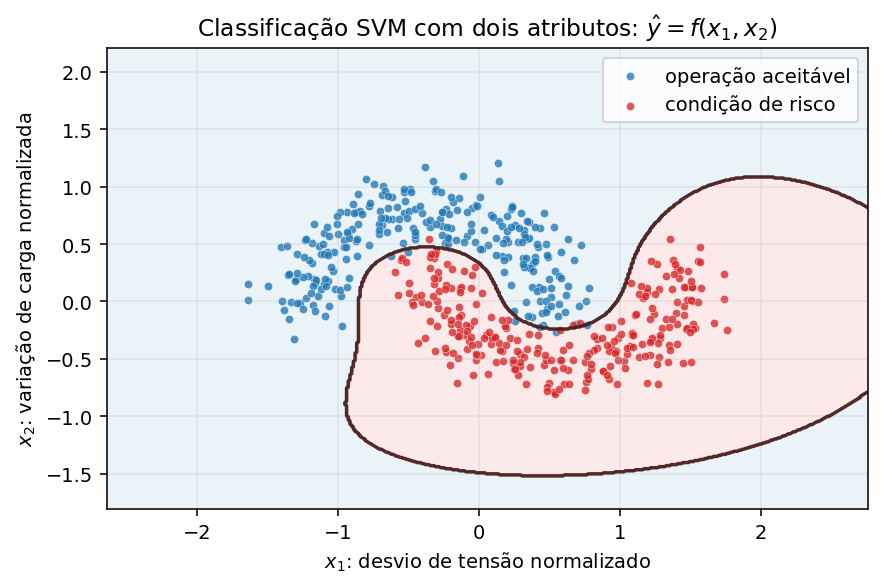

In [10]:
# Exemplo sintético: duas regiões operacionais não separáveis por uma reta.
# Entrada do modelo: x = [x1, x2].
# x1 = desvio de tensão normalizado; x2 = variação de carga normalizada.
# y = 0 indica operação aceitável; y = 1 indica condição de risco.
X_svm2d, y_svm2d = make_moons(n_samples=520, noise=0.18, random_state=7)
X_svm2d[:, 0] = 0.9 * X_svm2d[:, 0] - 0.35
X_svm2d[:, 1] = 0.9 * X_svm2d[:, 1] - 0.10

svm_2d = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=10, gamma="scale"))
])
svm_2d.fit(X_svm2d, y_svm2d)

fig, ax = plt.subplots(figsize=(6.4, 4.3))
region_cmap = ListedColormap(["#9ecae1", "#f4a3a3"])
DecisionBoundaryDisplay.from_estimator(
    svm_2d,
    X_svm2d,
    response_method="predict",
    alpha=0.22,
    cmap=region_cmap,
    grid_resolution=250,
    ax=ax,
)

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 450), np.linspace(y_min, y_max, 450))
zz = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
ax.contour(xx, yy, zz, levels=[0.5], colors="#4a1f1f", linewidths=1.8, alpha=0.95)

labels = {0: "operação aceitável", 1: "condição de risco"}
colors = {0: "#1f77b4", 1: "#d62728"}
for cls in [0, 1]:
    idx = y_svm2d == cls
    ax.scatter(
        X_svm2d[idx, 0],
        X_svm2d[idx, 1],
        s=18,
        alpha=0.78,
        c=colors[cls],
        label=labels[cls],
        edgecolor="white",
        linewidth=0.25,
    )

ax.set_xlabel("$x_1$: desvio de tensão normalizado")
ax.set_ylabel("$x_2$: variação de carga normalizada")
ax.set_title("Classificação SVM com dois atributos: $\\hat y=f(x_1,x_2)$")
ax.legend(frameon=True, loc="upper right")
ax.grid(alpha=0.22)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_svm_2d_engenharia.png", bbox_inches="tight", dpi=220)
display(fig)
plt.close()

## SVM em `scikit-learn`

O código abaixo é o mesmo pipeline de SVM apresentado nos slides.

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", C=10, gamma="scale",
                random_state=42))
])
svm.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['tau1','tau2','tau3',...,'g2','g3','g4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Comentários do slide:

- `StandardScaler`: coloca as variáveis em escala comparável.
- `kernel="rbf"`: permite fronteira não linear.
- `C=10`: controla a regularização; valores maiores penalizam mais os erros no treino e reduzem a regularização efetiva.
- `gamma="scale"`: define automaticamente o alcance do RBF.
- `random_state=42`: fixa a aleatoriedade interna.
- O `Pipeline` evita vazamento: o escalonador é ajustado só no treino.

# Comparação experimental

## Resultados no conjunto de teste

Precisão, recall e F1 foram calculados para a classe `stable`.

In [12]:
metrics = []
for name, model in models.items():
    pred = model.predict(X_test)
    metrics.append({
        "Modelo": name,
        "Acurácia": accuracy_score(y_test, pred),
        "Precisão": precision_score(y_test, pred, pos_label=stable_label),
        "Recall": recall_score(y_test, pred, pos_label=stable_label),
        "F1": f1_score(y_test, pred, pos_label=stable_label),
    })

metrics_df = pd.DataFrame(metrics)
metrics_df.round(3)

,Modelo,Acurácia,Precisão,Recall,F1
0,Árvore de decisão,0.767,0.706,0.612,0.656
1,Floresta aleatória,0.928,0.881,0.927,0.904
2,SVM RBF,0.972,0.964,0.959,0.962


Leitura apresentada nos slides:

- A árvore é o modelo mais simples, mas perde muitos casos `stable`.
- A floresta melhora todas as métricas em relação à árvore única.
- A SVM RBF obteve o melhor desempenho neste conjunto de dados.

## Matrizes de confusão

Figura usada no slide com as matrizes de confusão dos três modelos.

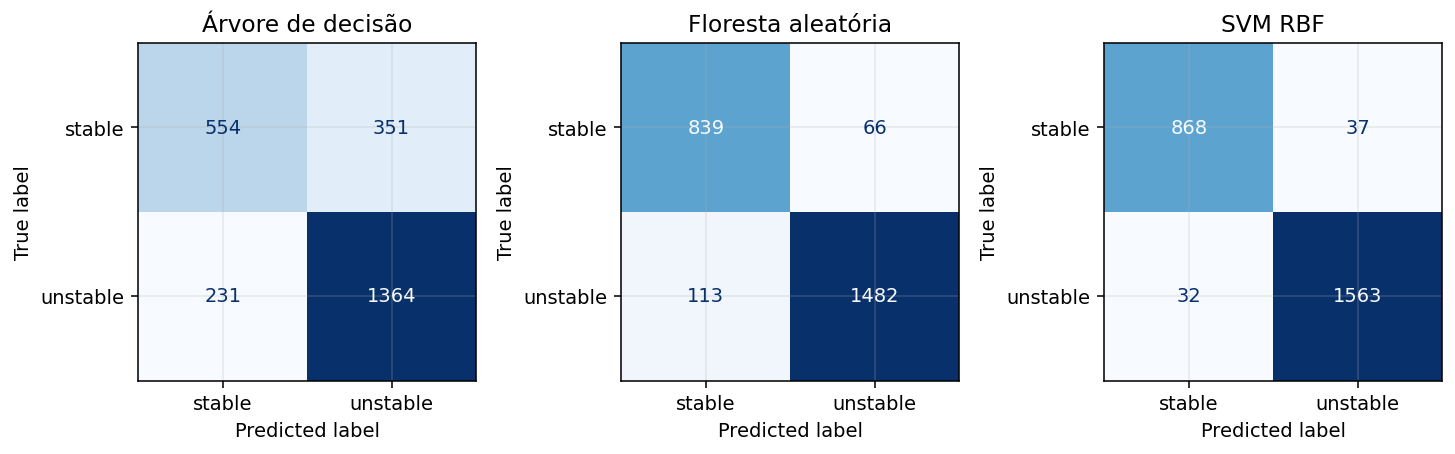

WindowsPath('figuras_aula_13_dt_rf_svm/05_matrizes_confusao.png')

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        model.predict(X_test),
        display_labels=label_encoder.classes_,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(name)
savefig("05_matrizes_confusao.png")

## Leitura dos modelos

- Árvore: mais interpretável, boa para discutir regras, mas pode ter alta variância.
- Floresta: geralmente melhor desempenho em dados tabulares e robusta a interações não lineares.
- SVM RBF: fronteiras suaves e fortes, mas menos transparente e sensível a escala/hiperparâmetros.
- Em aplicações de Engenharia, métricas devem refletir risco operacional sempre: falso estável pode ser mais grave que falso instável.
- Boas práticas: separar treino/teste antes de ajustes, usar validação cruzada e documentar variáveis removidas.

## Exercícios sugeridos

1. Treine Árvores com `max_depth` de 1 a 15 e faça o gráfico treino versus teste.
2. Troque o kernel RBF por linear e polinomial. Compare F1, Precisão, Recall e tempo de treino.
3. Defina uma métrica que penalize mais classificar uma rede instável como estável.

## Referências

- GRUS, Joel. *Data Science do Zero: Noções Fundamentais com Python*. 2ª ed. Alta Books, 2020.
- Arzamasov, V. (2018). *Electrical Grid Stability Simulated Data* [Dataset]. UCI Machine Learning Repository. DOI: `10.24432/C5PG66`.
- Pedregosa et al. *Scikit-learn: Machine Learning in Python*. JMLR, 2011.